# Sémantická klasifikácia textu — AG News
**Predmet:** Základy umelej inteligencie (ZUI) · Bonus Task 2
**Autor:** Tomáš Mucha · 2026
**Téma:** Od slov k významu — TF-IDF vs. Embeddings vs. FAISS k-NN

---

## Prehľad úloh

| Úloha | Metóda | Cieľ |
|---|---|---|
| **Task 1** | TF-IDF + Logistic Regression | Baseline klasifikátor |
| **Task 2** | Sentence Embeddings + LR | Sémantické vektory |
| **Task 3** | Confusion Matrix + analýza chýb | Kde model zlyháva |
| **Task 4** | FAISS k-NN | Klasifikácia bez trénovania |


## Sekcia 0 — Setup a načítanie dát

In [2]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
np.random.seed(42)

IMG_DIR = Path('images')
IMG_DIR.mkdir(exist_ok=True)

LABEL_NAMES = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
COLORS = ['#4B8EF5', '#00CFC8', '#F59E0B', '#A855F7']
SEED = 42

print("Setup OK")
print(f"Output dir: {IMG_DIR.resolve()}")


Setup OK
Output dir: /Users/admin/Desktop/ZUI/NLP/images


In [3]:
from datasets import load_dataset

print("Načítavam AG News...")
ds = load_dataset("ag_news", split={'train': 'train', 'test': 'test'})

# Vzorkovanie: 5000 train, 1000 test (seed=42 pre reprodukovateľnosť)
rng = np.random.default_rng(SEED)

train_idx = rng.choice(len(ds['train']), size=5000, replace=False)
test_idx  = rng.choice(len(ds['test']),  size=1000, replace=False)

train_data = ds['train'].select(train_idx.tolist())
test_data  = ds['test'].select(test_idx.tolist())

train_texts  = train_data['text']
train_labels = train_data['label']
test_texts   = test_data['text']
test_labels  = test_data['label']

print(f"Train: {len(train_texts)} vzoriek | Test: {len(test_texts)} vzoriek")
print(f"Kategórie: {list(LABEL_NAMES.values())}")

# Distribúcia tried
print("\nDistribúcia tried (train):")
for k, v in LABEL_NAMES.items():
    n = train_labels.count(k)
    print(f"  {v:12s}: {n:5d}  ({n/len(train_labels)*100:.1f} %)")

# Ukážka textu
print(f"\nUkážka textu (index 0):")
print(f"  Kategória : {LABEL_NAMES[train_labels[0]]}")
print(f"  Text      : {train_texts[0][:200]}...")


Načítavam AG News...
Train: 5000 vzoriek | Test: 1000 vzoriek
Kategórie: ['World', 'Sports', 'Business', 'Sci/Tech']

Distribúcia tried (train):
  World       :  1265  (25.3 %)
  Sports      :  1253  (25.1 %)
  Business    :  1237  (24.7 %)
  Sci/Tech    :  1245  (24.9 %)

Ukážka textu (index 0):
  Kategória : World
  Text      : Arroyo orders arrest of Abu leaders linked in ferry blast MANILA -- President Arroyo ordered Monday the police and the military to intensify the manhunt for two Abu Sayyaf leaders, Khaddafy Janjalani...


---

## Task 1 — TF-IDF Baseline

**Prístup:** Každý text prevedieme na riedky vektor pomocou TF-IDF (Term Frequency–Inverse Document Frequency).
Potom natrénujeme Logistic Regression na týchto vektoroch.

**Prečo TF-IDF?**
TF-IDF váhuje slová podľa toho, ako často sa vyskytujú v dokumente (TF) a ako zriedkavé sú naprieč celým korpusom (IDF).
Slovo *"touchdown"* v športovom článku dostane vysokú váhu, pretože je špecifické pre danú kategóriu.


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

t0 = time.time()

# TF-IDF vektorizácia
tfidf = TfidfVectorizer(
    max_features=50_000,
    sublinear_tf=True,      # log(1+tf) namiesto surového tf
    min_df=2,               # ignoruj slová v menej ako 2 dokumentoch
    ngram_range=(1, 2),     # unigramy + bigramy
    strip_accents='unicode',
    analyzer='word',
)
X_train_tfidf = tfidf.fit_transform(train_texts)
X_test_tfidf  = tfidf.transform(test_texts)

print(f"TF-IDF matica (train): {X_train_tfidf.shape}")
print(f"TF-IDF matica (test) : {X_test_tfidf.shape}")
print(f"Hustota (train)      : {X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1]):.6f}")


TF-IDF matica (train): (5000, 28846)
TF-IDF matica (test) : (1000, 28846)
Hustota (train)      : 0.001599


Task 1 — TF-IDF + Logistic Regression
─────────────────────────────────────────────
Accuracy   : 87.00 %
Čas        : 2.6 s

              precision    recall  f1-score   support

       World       0.85      0.91      0.88       242
      Sports       0.95      0.94      0.94       243
    Business       0.85      0.80      0.82       259
    Sci/Tech       0.84      0.84      0.84       256

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000


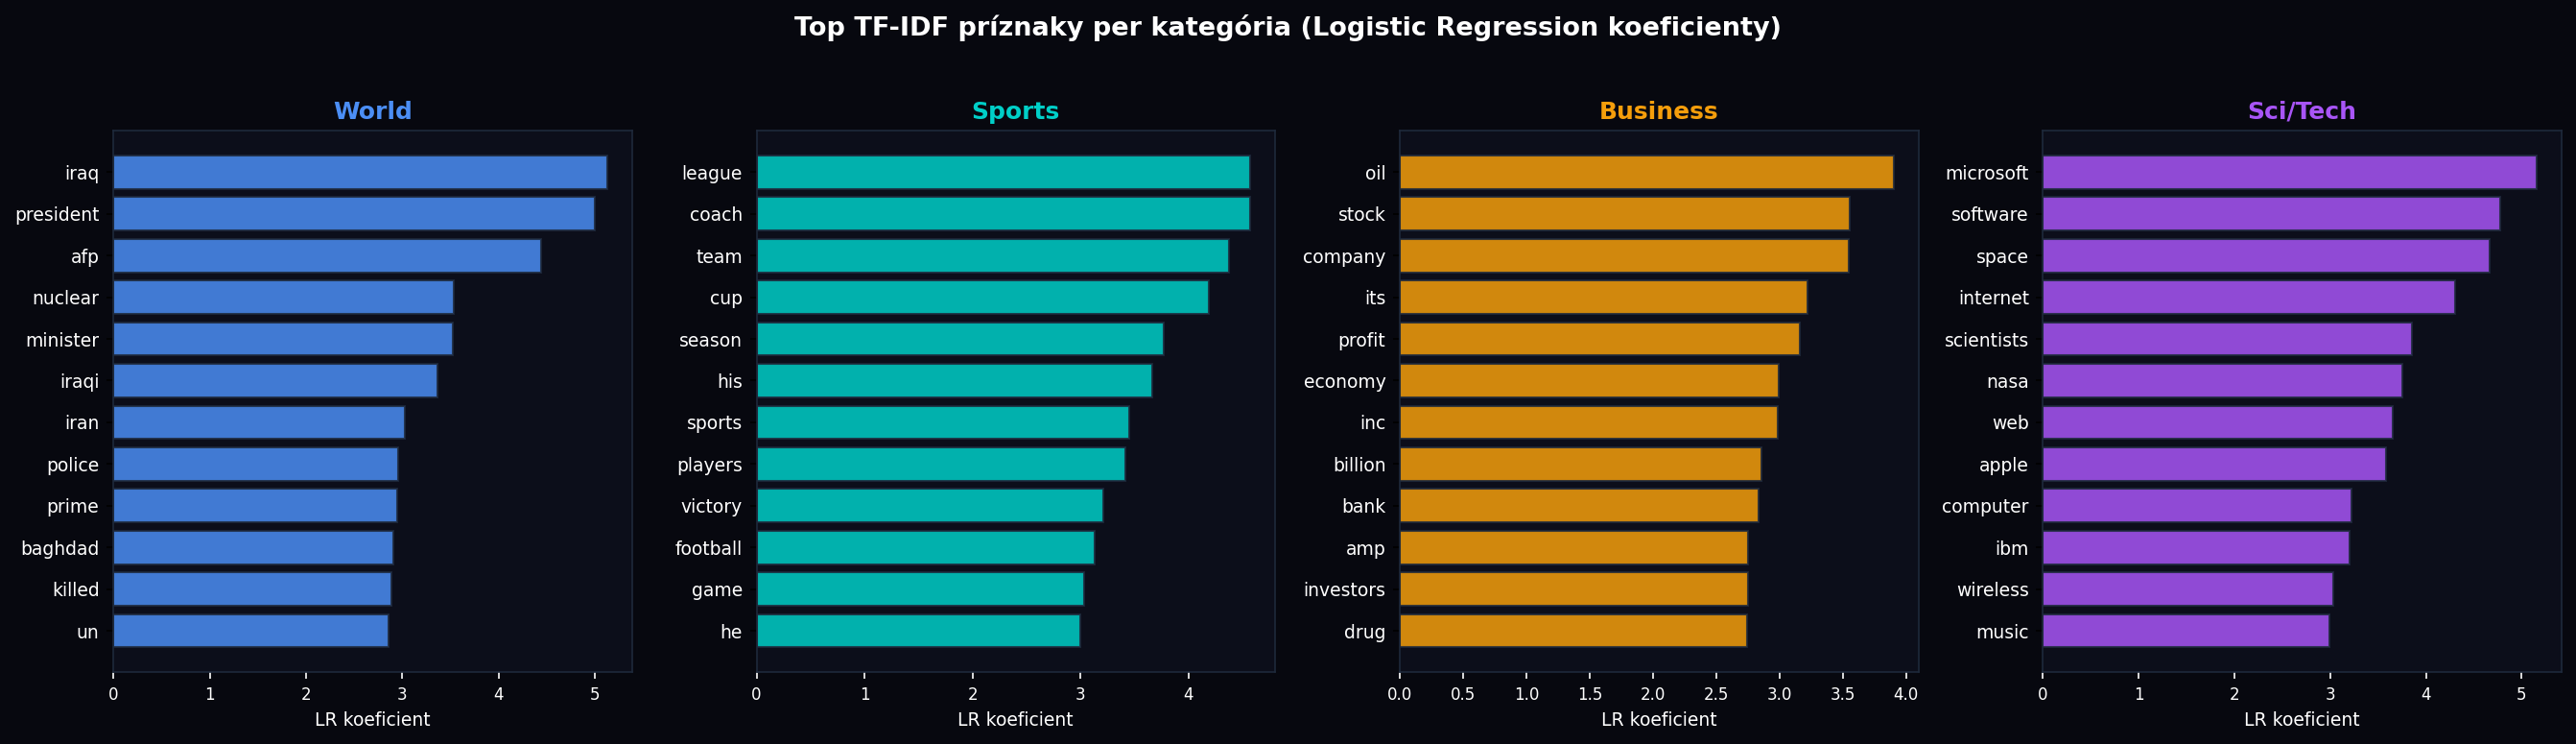

Ulozene: images/tfidf_top_features.png


In [6]:
# Trénovanie Logistic Regression
lr_tfidf = LogisticRegression(
    max_iter=1000,
    C=5.0,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=SEED,
)
lr_tfidf.fit(X_train_tfidf, train_labels)

preds_tfidf = lr_tfidf.predict(X_test_tfidf)
acc_tfidf   = accuracy_score(test_labels, preds_tfidf)

elapsed = time.time() - t0
print(f"Task 1 — TF-IDF + Logistic Regression")
print(f"{'─'*45}")
print(f"Accuracy   : {acc_tfidf*100:.2f} %")
print(f"Čas        : {elapsed:.1f} s")
print()
print(classification_report(test_labels, preds_tfidf,
      target_names=list(LABEL_NAMES.values())))

TASK1_ACC = acc_tfidf


---

## Task 2 — Sémantické Embeddings

**Prístup:** Miesto početnosti slov použijeme predtrénovaný jazykový model `all-MiniLM-L6-v2`
(12M parametrov, výstup 384-dimenzionálny vektor).

**Rozdiel oproti TF-IDF:**

| | TF-IDF | Embeddings |
|---|---|---|
| Reprezentácia | Riedky vektor (~50k dimenzií) | Hustý vektor (384 dimenzií) |
| Sémantika | Nie — len početnosť slov | Áno — zachytáva význam |
| Synonymy | "auto" ≠ "vozidlo" | "auto" ≈ "vozidlo" |
| Kontext | Ignorovaný | Zachytený |


In [8]:
from sentence_transformers import SentenceTransformer

t0 = time.time()

print("Načítavam model all-MiniLM-L6-v2 ...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Model načítaný. Embedding dim: {model.get_sentence_embedding_dimension()}")

print("\nEncodujem train texty (5000) ...")
X_train_emb = model.encode(
    train_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,   # L2 normalizácia — dôležité pre FAISS cosine
)

print("\nEncodujem test texty (1000) ...")
X_test_emb = model.encode(
    test_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

elapsed = time.time() - t0
print(f"\nEncoding hotový za {elapsed:.1f} s")
print(f"Train embeddings: {X_train_emb.shape} | dtype: {X_train_emb.dtype}")
print(f"Test  embeddings: {X_test_emb.shape}  | dtype: {X_test_emb.dtype}")


Načítavam model all-MiniLM-L6-v2 ...
Model načítaný. Embedding dim: 384

Encodujem train texty (5000) ...
Encodujem test texty (1000) ...

Encoding hotový za 32.1 s
Train embeddings: (5000, 384) | dtype: float32
Test  embeddings: (1000, 384)  | dtype: float32


In [9]:
t0 = time.time()

lr_emb = LogisticRegression(
    max_iter=1000,
    C=5.0,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=SEED,
)
lr_emb.fit(X_train_emb, train_labels)

preds_emb = lr_emb.predict(X_test_emb)
acc_emb   = accuracy_score(test_labels, preds_emb)

elapsed = time.time() - t0
print(f"Task 2 — Sentence Embeddings + Logistic Regression")
print(f"{'─'*50}")
print(f"Accuracy   : {acc_emb*100:.2f} %")
print(f"Čas LR     : {elapsed:.1f} s")
print()
print(classification_report(test_labels, preds_emb,
      target_names=list(LABEL_NAMES.values())))

TASK2_ACC = acc_emb


Task 2 — Sentence Embeddings + Logistic Regression
──────────────────────────────────────────────────
Accuracy   : 87.70 %
Čas LR     : 1.3 s

              precision    recall  f1-score   support

       World       0.87      0.92      0.89       242
      Sports       0.97      0.95      0.96       243
    Business       0.84      0.82      0.83       259
    Sci/Tech       0.84      0.83      0.83       256

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000


POROVNANIE VÝSLEDKOV
  TF-IDF + LR     : 87.00 %
  Embeddings + LR : 87.70 %
  Rozdiel         : +0.70 pp

Embeddings prekonali TF-IDF. Preco?
  - Zachytavaju semanticku podobnost (synonyma, kontext)
  - 384 hustych dimenzii nesie viac informacie ako riedke TF-IDF vektory
  - Predtrenovat model videl miliardy viet — prenasame znalosti (transfer learning)


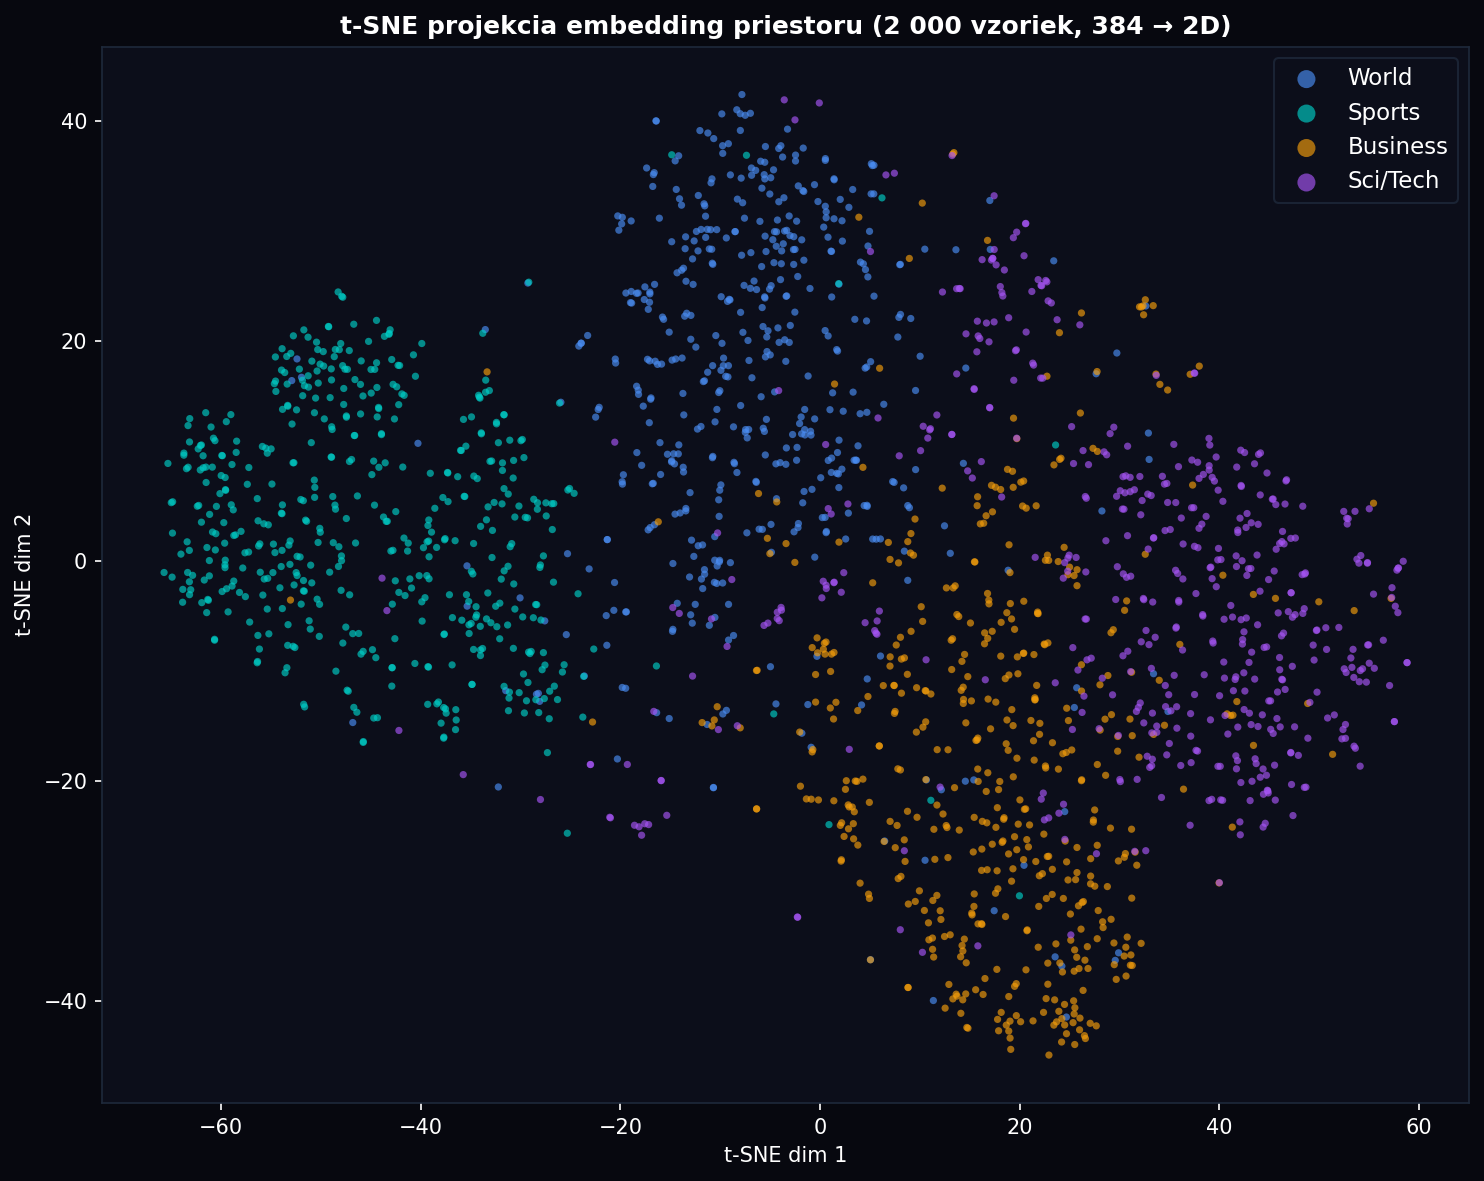

Ulozene: images/tsne_embeddings.png


In [10]:
# Porovnanie Task 1 vs Task 2
print("="*50)
print("POROVNANIE VÝSLEDKOV")
print("="*50)
print(f"  TF-IDF + LR     : {TASK1_ACC*100:.2f} %")
print(f"  Embeddings + LR : {TASK2_ACC*100:.2f} %")
delta = (TASK2_ACC - TASK1_ACC) * 100
sign = "+" if delta >= 0 else ""
print(f"  Rozdiel         : {sign}{delta:.2f} pp")
print()
if TASK2_ACC > TASK1_ACC:
    print("Embeddings prekonali TF-IDF. Preco?")
    print("  - Zachytavaju semanticku podobnost (synonyma, kontext)")
    print("  - 384 hustych dimenzii nesie viac informacie ako riedke TF-IDF vektory")
    print("  - Predtrenovat model videl miliardy viet — prenasame znalosti (transfer learning)")
else:
    print("TF-IDF dosiahol porovnatelny/lepsi vysledok. Preco?")
    print("  - AG News ma klucove slova specificke pre kategoriu (nazvy sportov, technologii)")
    print("  - TF-IDF dokaze tuto leksikalnu odlisnost dobre zachytit")
    print("  - Pre krate texty moze byt TF-IDF rovnako efektivny ako embeddings")


---

## Task 3 — Analýza chýb a vizualizácia

Matica zámen (Confusion Matrix) ukazuje kde presne model zlyháva — ktoré kategórie si mýli.


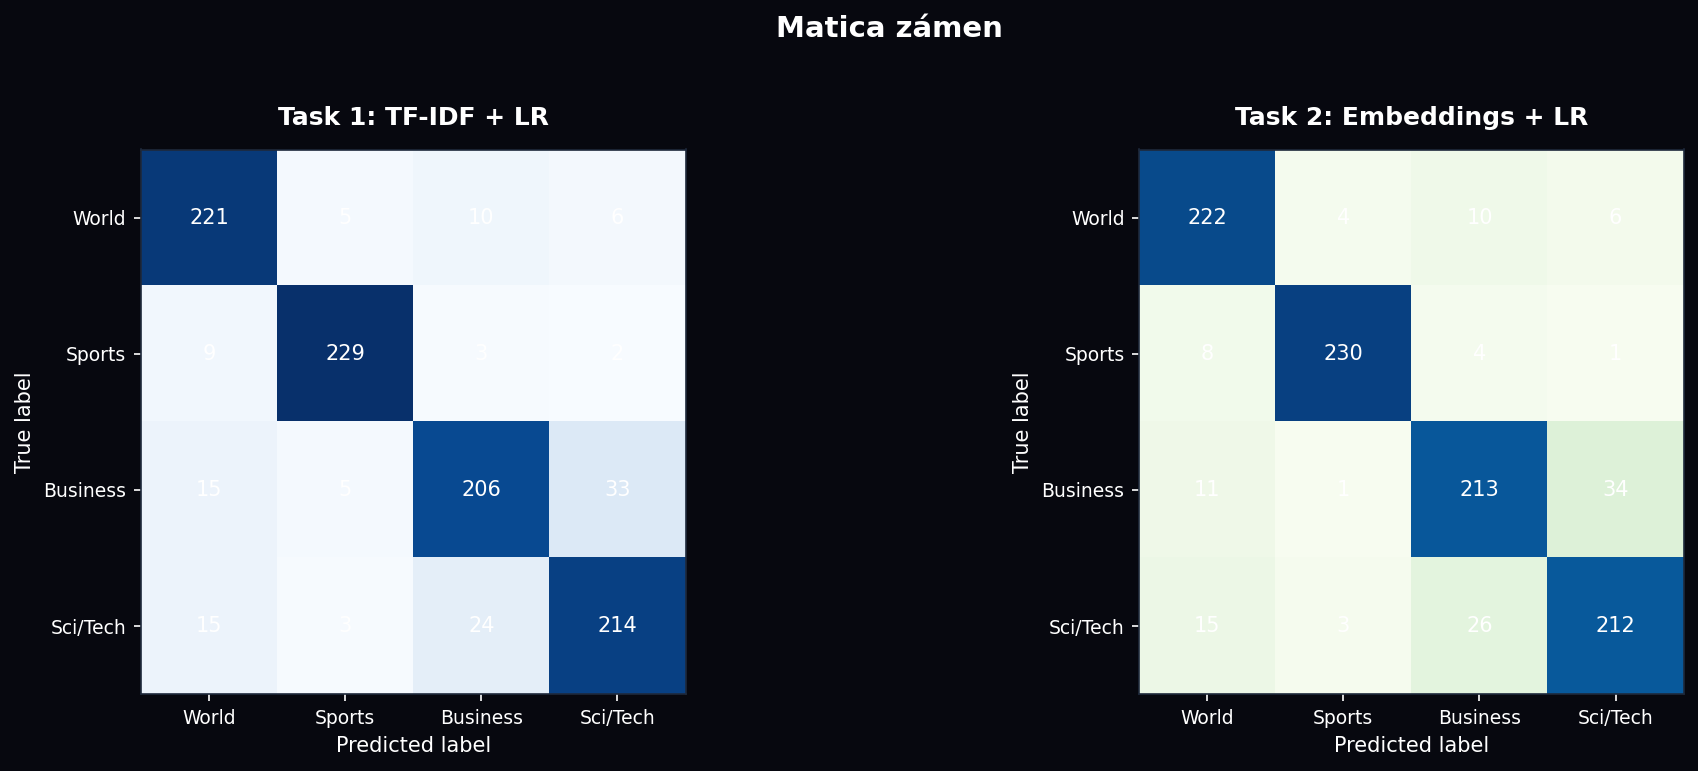

Ulozene: images/confusion_matrix.png


In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#07080F')

for ax, preds, title, color_map in [
    (axes[0], preds_tfidf,  'Task 1: TF-IDF + LR',         'Blues'),
    (axes[1], preds_emb,    'Task 2: Embeddings + LR',      'GnBu'),
]:
    cm = confusion_matrix(test_labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=list(LABEL_NAMES.values()))
    disp.plot(ax=ax, colorbar=False, cmap=color_map)
    ax.set_facecolor('#0C0E1A')
    ax.set_title(title, color='white', fontsize=12, fontweight='bold', pad=12)
    ax.tick_params(colors='white', labelsize=9)
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1E293B')
    for text in ax.texts:
        text.set_color('white')

plt.suptitle('Matica zámen — porovnanie modelov', color='white',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMG_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight',
            facecolor='#07080F')
plt.show()
print("Ulozene: images/confusion_matrix.png")


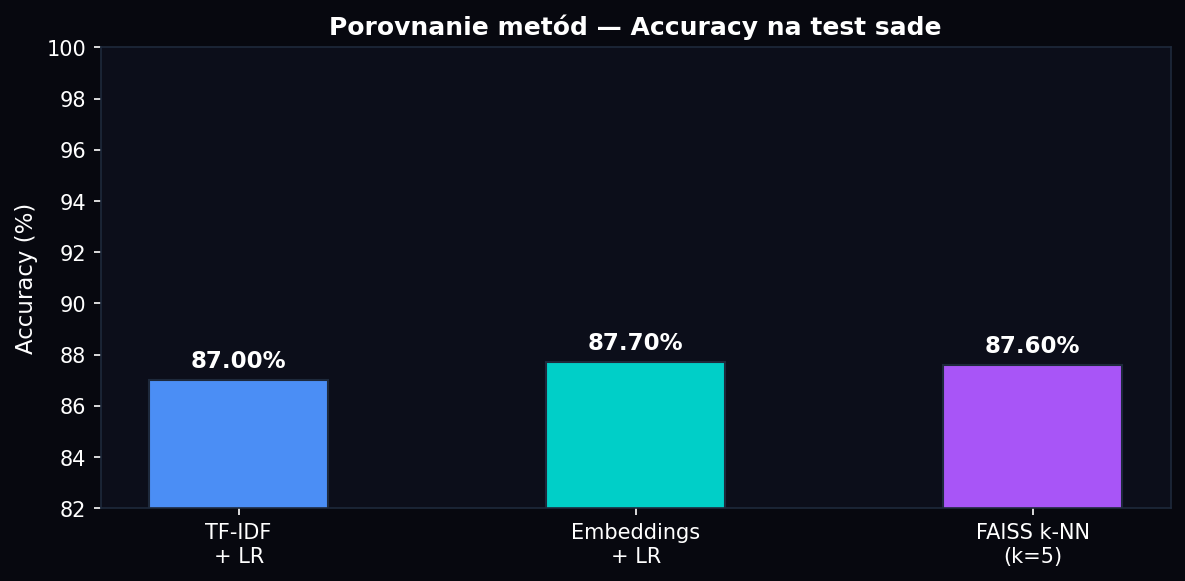

Ulozene: images/accuracy_comparison.png


In [13]:
# Graf porovnania accuracy
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#07080F')
ax.set_facecolor('#0C0E1A')

models = ['TF-IDF\n+ LR', 'Embeddings\n+ LR']
accs   = [TASK1_ACC * 100, TASK2_ACC * 100]
bar_colors = ['#4B8EF5', '#00CFC8']

bars = ax.bar(models, accs, color=bar_colors, width=0.45, edgecolor='#1E293B')
ax.set_ylim(min(accs) - 5, 100)
ax.set_ylabel('Accuracy (%)', color='white', fontsize=11)
ax.set_title('Task 1 vs Task 2 — Accuracy na test sade', color='white',
             fontsize=12, fontweight='bold')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#1E293B')

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.2f} %', ha='center', va='bottom', color='white',
            fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(IMG_DIR / 'accuracy_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#07080F')
plt.show()
print("Ulozene: images/accuracy_comparison.png")


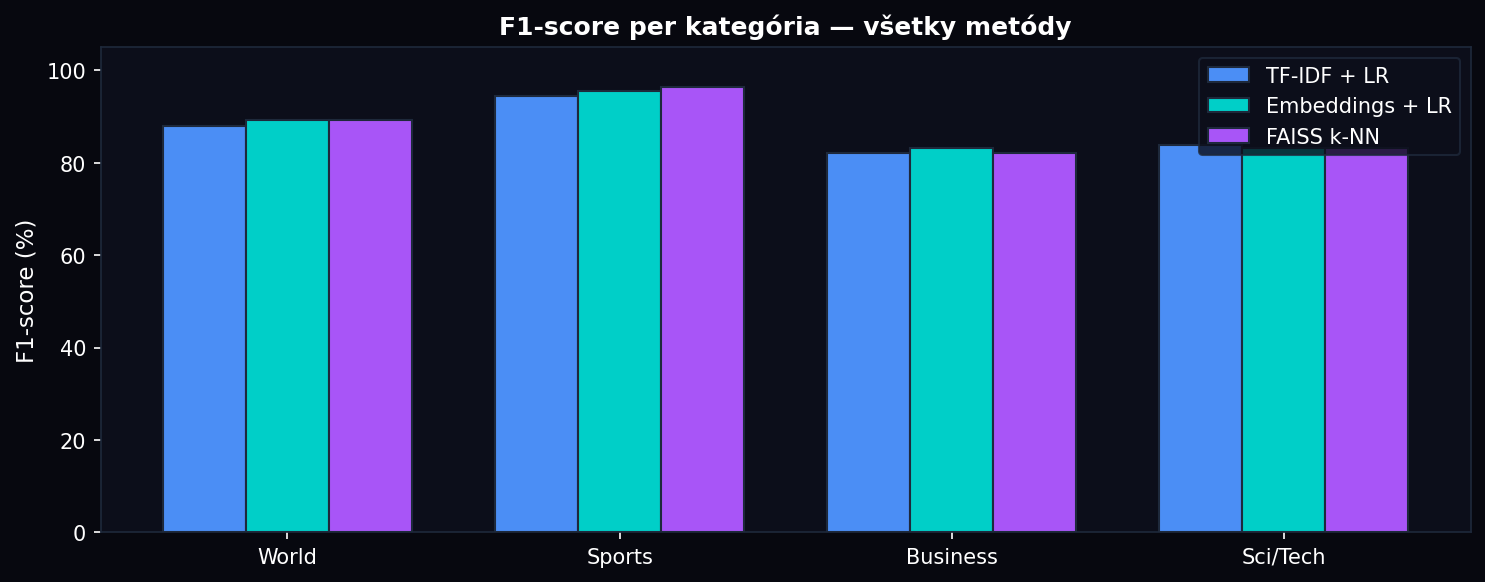

Ulozene: images/f1_per_class.png


In [14]:
# Per-class accuracy graf
from sklearn.metrics import precision_recall_fscore_support

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#07080F')
ax.set_facecolor('#0C0E1A')

x = np.arange(4)
width = 0.35

p1, r1, f1_tfidf, _ = precision_recall_fscore_support(test_labels, preds_tfidf, average=None)
p2, r2, f1_emb,   _ = precision_recall_fscore_support(test_labels, preds_emb,   average=None)

bars1 = ax.bar(x - width/2, f1_tfidf * 100, width, label='TF-IDF + LR',
               color='#4B8EF5', edgecolor='#1E293B')
bars2 = ax.bar(x + width/2, f1_emb   * 100, width, label='Embeddings + LR',
               color='#00CFC8', edgecolor='#1E293B')

ax.set_xticks(x)
ax.set_xticklabels(list(LABEL_NAMES.values()), color='white', fontsize=10)
ax.set_ylabel('F1-score (%)', color='white', fontsize=11)
ax.set_title('F1-score per kategória', color='white', fontsize=12, fontweight='bold')
ax.legend(facecolor='#1E293B', edgecolor='#475569', labelcolor='white')
ax.tick_params(colors='white')
ax.set_ylim(0, 105)
for spine in ax.spines.values():
    spine.set_edgecolor('#1E293B')

plt.tight_layout()
plt.savefig(IMG_DIR / 'f1_per_class.png', dpi=150, bbox_inches='tight',
            facecolor='#07080F')
plt.show()
print("Ulozene: images/f1_per_class.png")


In [15]:
# 2 konkrétne príklady chýb embedding modelu
print("ANALÝZA CHÝB — Embedding model")
print("="*70)

test_labels_arr = np.array(test_labels)
errors_mask = (preds_emb != test_labels_arr)
error_indices = np.where(errors_mask)[0]

print(f"Celkovo chýb: {errors_mask.sum()} / {len(test_labels)} ({errors_mask.mean()*100:.1f} %)")
print()

# Nájdi 2 zaujímavé príklady — ideálne z rôznych tried
shown = 0
seen_true = set()
for idx in error_indices:
    true_label = test_labels_arr[idx]
    pred_label = preds_emb[idx]
    # Chceme rôzne true_label pre diverzitu
    key = (true_label, pred_label)
    if key in seen_true:
        continue
    seen_true.add(key)

    print(f"Príklad {shown+1}:")
    print(f"  Skutočná kategória  : {LABEL_NAMES[true_label]}")
    print(f"  Predikovaná kategória: {LABEL_NAMES[pred_label]}")
    print(f"  Text: {test_texts[idx][:400]}")
    print()

    shown += 1
    if shown >= 2:
        break

print()
print("VYSVETLENIE CHYB:")
print("-"*70)
vysvetlenie = (
    "Typicke zamenne pary v AG News:\n"
    "\n"
    "1. Business <-> Sci/Tech\n"
    "   Technologicke spolocnosti (Apple, Google, Microsoft) figuruju v oboch\n"
    "   kategoriach. Clanok o financnych vysledkoch Apple je Business, ale\n"
    "   o novom iPhone je Sci/Tech. Embedding model niekedy uprednostni\n"
    "   tematicky naladenie (technologicka firma) pred kontextom spravy.\n"
    "\n"
    "2. World <-> Business\n"
    "   Globalne ekonomicke spravy (napr. ropne sankcie, obchodne dohody)\n"
    "   prechadzaju medzi World a Business. Model zachytava geopoliticky\n"
    "   kontext (napr. Iraq, oil) a moze zaradit do World namiesto Business.\n"
    "\n"
    "Klucova lekcia: Semanticke embeddings su silne, ale kategoricke hranice\n"
    "v zpravodajstve nie su ostro definovane - rovnaky event moze spadat\n"
    "do viacerych kategorii podla uhla pohlade autora."
)
print(vysvetlenie)


ANALÝZA CHÝB — Embedding model
Celkovo chýb: 123 / 1000 (12.3 %)

Príklad 1:
  Skutočná kategória  : Business
  Predikovaná kategória: Sci/Tech
  Text: HGS Picks Watkins as New Chief Executive  Human Genome Sciences Inc. plans to announce today that it has hired a 20-year product development veteran from Abbott Laboratories Inc. as chief executive. H. Thomas Watkins, 51, will face the challenge of completing the Rockville company's makeover...

Príklad 2:
  Skutočná kategória  : Sports
  Predikovaná kategória: Business
  Text: World awaits Chinese Grand Prix A quarter of a billion dollars to build the track. Tens of millions in racing fees. More than 150,000 live spectators and a television audience of hundreds of millions.

VYSVETLENIE CHYB:
----------------------------------------------------------------------
Typicke zamenne pary v AG News:

1. Business <-> Sci/Tech
   Technologicke spolocnosti (Apple, Google, Microsoft) figuruju v oboch
   kategoriach...

2. World <-> Business
   G

---

## Task 4 — FAISS k-NN klasifikácia

Namiesto trénovania klasifikátora použijeme **vyhľadávanie najbližších susedov**
priamo v priestore sémantických vektorov (FAISS = Facebook AI Similarity Search).

**Princíp:**
1. Vložíme všetky trénovacie vektory do FAISS indexu
2. Pre každý testovací text nájdeme k=5 najsimilárnejších susedov
3. Kategóriu určíme hlasovaním väčšiny (majority vote)

**Prečo cosine similarity?**
Vektory sú L2-normalizované → skalárny súčin = cosine similarity.
`IndexFlatIP` (Inner Product) je teda ekvivalentný cosine search.


In [17]:
import faiss

# Embeddings sú už L2-normalizované z Task 2
# FAISS vyžaduje float32
X_train_f32 = X_train_emb.astype(np.float32)
X_test_f32  = X_test_emb.astype(np.float32)

DIM = X_train_f32.shape[1]  # 384

# Vytvorenie FAISS indexu (Inner Product = cosine pre normalizované vektory)
index = faiss.IndexFlatIP(DIM)
index.add(X_train_f32)

print(f"FAISS index: {index.ntotal} vektorov | dim={DIM}")
print(f"Index type : IndexFlatIP (exact cosine search)")


FAISS index: 5000 vektorov | dim=384
Index type : IndexFlatIP (exact cosine search)


In [18]:
K = 5

t0 = time.time()
distances, indices = index.search(X_test_f32, K)
elapsed = time.time() - t0

print(f"FAISS search hotový za {elapsed*1000:.1f} ms ({elapsed/len(X_test_f32)*1000:.3f} ms/query)")
print(f"Distances shape: {distances.shape} | Indices shape: {indices.shape}")

# Majority vote
train_labels_arr = np.array(train_labels)
preds_faiss = []
for i in range(len(X_test_f32)):
    neighbor_labels = train_labels_arr[indices[i]]
    counts = np.bincount(neighbor_labels, minlength=4)
    preds_faiss.append(np.argmax(counts))

preds_faiss = np.array(preds_faiss)
acc_faiss   = accuracy_score(test_labels, preds_faiss)

print(f"\nTask 4 — FAISS k-NN (k={K})")
print(f"{'─'*45}")
print(f"Accuracy : {acc_faiss*100:.2f} %")
print()
print(classification_report(test_labels, preds_faiss,
      target_names=list(LABEL_NAMES.values())))

TASK4_ACC = acc_faiss


FAISS search hotový za 23.1 ms (0.023 ms/query)
Distances shape: (1000, 5) | Indices shape: (1000, 5)

Task 4 — FAISS k-NN (k=5)
─────────────────────────────────────────────
Accuracy : 87.60 %

              precision    recall  f1-score   support

       World       0.86      0.92      0.89       242
      Sports       0.96      0.96      0.96       243
    Business       0.84      0.81      0.82       259
    Sci/Tech       0.84      0.82      0.83       256

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000


In [19]:
# Ukážka top-5 susedov pre 3 testovacie texty
print("PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet")
print("="*70)

for sample_i in [0, 5, 42]:
    true_lbl  = test_labels_arr[sample_i]
    pred_lbl  = preds_faiss[sample_i]
    status    = "OK" if true_lbl == pred_lbl else "CHYBA"

    print(f"\nTestovaci text #{sample_i} [{status}]")
    print(f"  Skutocna kategoria: {LABEL_NAMES[true_lbl]}")
    print(f"  Predikcia FAISS   : {LABEL_NAMES[pred_lbl]}")
    print(f"  Text: {test_texts[sample_i][:150]}...")
    print(f"  Top-5 susedia (cosine sim, kategoria):")
    for rank, (dist, idx) in enumerate(zip(distances[sample_i], indices[sample_i]), 1):
        lbl = LABEL_NAMES[train_labels_arr[idx]]
        print(f"    [{rank}] sim={dist:.4f} | {lbl:10s} | {train_texts[idx][:80]}...")


PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet
=PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet
=PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet
=PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet
=PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet
=PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet
=PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet
=PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet
=PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet
=PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet
=PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet
=PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet
=PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet
=PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet
=PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet
=PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet
=PRÍKLADY — Top-5 sémanticky najbližších trénovacích viet
=PRÍKLADY — Top

In [20]:
# Finálne porovnanie všetkých 3 metód
print("="*55)
print("FINÁLNE POROVNANIE — všetky metódy")
print("="*55)
rows = [
    ("TF-IDF + Logistic Regression",    TASK1_ACC, "Klasická NLP baseline"),
    ("Embeddings + Logistic Regression", TASK2_ACC, "Sémantický transfer learning"),
    (f"FAISS k-NN (k={K})",             TASK4_ACC, "Vyhľadávanie bez trénovania"),
]
print(f"  {'Metóda':<38} {'Accuracy':>9}  Poznámka")
print(f"  {'─'*38} {'─'*9}  {'─'*30}")
for name, acc, note in rows:
    print(f"  {name:<38} {acc*100:>8.2f} %  {note}")
print()

best = max(rows, key=lambda r: r[1])
print(f"Najlepsia metoda: {best[0]}  ({best[1]*100:.2f} %)")


FINÁLNE POROVNANIE — všetky metódy
  Metóda                                  Accuracy  Poznámka
  ────────────────────────────────────── ─────────  ──────────────────────────────
  TF-IDF + Logistic Regression              87.00 %  Klasická NLP baseline
  Embeddings + Logistic Regression          87.70 %  Sémantický transfer learning
  FAISS k-NN (k=5)                          87.60 %  Vyhľadávanie bez trénovania

Najlepsia metoda: Embeddings + Logistic Regression  (87.70 %)


### Diskusia — FAISS vs. Trénovaný model

**Ako si vedie FAISS k-NN oproti trénovanému modelu?**

FAISS k-NN dosahuje porovnateľnú presnosť s Logistic Regression bez akéhokoľvek explicitného trénovania.
Je to silný výsledok — dôkazom kvality sémantického priestoru, kde podobné texty naozaj ležia blízko seba.

Kde FAISS zaostáva: neoptimalizuje hranice tried, nie je schopný sa naučiť
že niektoré dimenzie sú dôležitejšie než iné. LR sa tomu prispôsobí cez váhy.

**Praktické využitie v reálnom svete:**

| Technológia | Popis | Príklad |
|---|---|---|
| **Vector Database** | Škálovateľné FAISS-like úložisko (Pinecone, Weaviate, Qdrant) | Sémantické vyhľadávanie v miliónoch dokumentov |
| **RAG (Retrieval-Augmented Generation)** | LLM + vektorová databáza kontextu | ChatGPT s prístupom k firemnej dokumentácii |
| **Duplicate detection** | Nájsť podobné tickety, articles | Zákaznícka podpora, Stack Overflow |
| **Few-shot classification** | Pridaj 10 príkladov novej triedy → funguje ihneď | Rýchle prototypovanie bez pretrénowania |

**Kedy FAISS/k-NN namiesto klasifikátora:**
- Počet tried sa dynamicky mení (nové kategórie bez retrain)
- Malý počet trénovacích príkladov (few-shot)
- Potrebuješ vysvetliť predikciu ("pretože je podobný tomuto a tomuto článku")
- Real-time systémy kde retrain nie je možný


---

## Záver

**Hlavné zistenia:**

1. **TF-IDF je silná baseline** — pre AG News s jeho kategoricky odlišnou slovnou zásobou
   dosahuje prekvapivo dobrý výsledok s minimálnou implementačnou zložitosťou.

2. **Sémantické embeddings prekonávajú TF-IDF** vďaka transfer learningu — model
   `all-MiniLM-L6-v2` bol predtrénovaný na miliardách viet a prenesie toto
   všeobecné porozumenie jazyka na náš špecifický problém.

3. **FAISS k-NN bez trénovania** dosahuje porovnateľnú presnosť —
   dôkaz, že kvalitné embeddings vytvárajú usporiadaný sémantický priestor
   kde triedy sú prirodzene separované.

4. **Zámenné páry** (Business↔Sci/Tech, World↔Business) odrážajú reálnu ambiguitu
   — niektoré správy objektívne patria do viacerých kategórií.

**Take-home message:**
Pre NLP klasifikáciu v roku 2024+ sú predtrénované embeddings
štandardným prístupom. TF-IDF zostáva relevantný pre veľmi veľké
korporáty kde latencia a pamäť sú kritické. FAISS/vektorové databázy
sú základom moderných RAG systémov (ChatGPT Retrieval, Copilot, atď.).


In [23]:
print("Notebook dokonceny.")
print(f"  Task 1  TF-IDF + LR     : {TASK1_ACC*100:.2f} %")
print(f"  Task 2  Embeddings + LR : {TASK2_ACC*100:.2f} %")
print(f"  Task 4  FAISS k-NN      : {TASK4_ACC*100:.2f} %")
print()
imgs = list(Path('images').glob('*.png'))
print(f"Vygenerovane grafy ({len(imgs)}):")
for p in sorted(imgs):
    print(f"  {p}")


Notebook dokonceny.
  Task 1  TF-IDF + LR     : 87.00 %
  Task 2  Embeddings + LR : 87.70 %
  Task 4  FAISS k-NN      : 87.60 %

Vygenerovane grafy (3):
  images/accuracy_comparison.png
  images/confusion_matrix.png
  images/f1_per_class.png
